In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sqlite3
import json
import time
import re
from datetime import timedelta
import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from rapidfuzz import process, fuzz
from tqdm import tqdm
import matplotlib.pyplot as plt


# **약물 관련 EDA**

In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query = """
SELECT COUNT(DISTINCT itemid) AS n_unique_drugs
FROM inputevents
WHERE amount IS NOT NULL;
"""
unique_drugs = pd.read_sql_query(query, conn)
print(unique_drugs)

inputevent에 나와있는 고유 itemid = 327개 정도

하지만 여기서 임상적으로 의미 있는 약물과 수액/영양/기타로 나뉨

In [ ]:
query = """
SELECT itemid, label, category
FROM d_items
WHERE linksto = 'inputevents';
"""
d_items = pd.read_sql_query(query, conn)

print(f"총 {len(d_items)}개 항목 로드됨 ✅")
print(d_items.head())

In [ ]:
db_path = '/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db'
conn = sqlite3.connect(db_path)


query = """
SELECT itemid, label, category
FROM d_items
WHERE linksto = 'inputevents';
"""
d_items = pd.read_sql_query(query, conn)

print(f"총 {len(d_items)}개 항목 로드됨 ✅")
display(d_items.head(10))


In [ ]:
query = """
SELECT DISTINCT category
FROM d_items
WHERE linksto = 'inputevents';
"""
categories = pd.read_sql_query(query, conn)

print(f"총 {len(categories)}개의 카테고리 유형이 있습니다 ✅")
display(categories)

| 번호 | Category 이름 | 설명 |
|:----:|:-----------------------------|:------------------------------------------------------------|
| **0** | **Fluids - Other (Not In Use)** | 과거에 사용되던 수액류 항목으로, 현재 데이터에서는 거의 사용되지 않음 |
| **1** | **Blood Products/Colloids** | 혈액 성분제제 및 교질 용액 (주로 저혈압, 쇼크, 패혈증 환자에게 사용) |
| **2** | **Fluids/Intake** | 일반적인 수액 및 경구 섭취량 (기초 유지용 수액 포함) |
| **3** | **Medications** | 순수 약물군 (혈관수축제, 진정제, 항응고제 등 핵심 치료제) |
| **4** | **Nutrition - Enteral** | 경장영양 (위관 또는 장관을 통한 영양공급, 환자가 식사 불가능할 때 사용) |
| **5** | **Nutrition - Parenteral** | 정맥영양 (PN, 정맥으로 영양공급 — LOS가 길고 합병증 위험이 높은 환자) |
| **6** | **Nutrition - Supplements** | 경구 영양보충제 (회복기 환자, 저영양 위험군 대상) |
| **7** | **Antibiotics** | 항생제 전용 카테고리 (감염 및 패혈증 치료 목적) |


In [ ]:
category_counts = (
    d_items.groupby('category')['itemid']
    .nunique()
    .reset_index()
    .rename(columns={'itemid': 'n_items'})
    .sort_values('n_items', ascending=False)
)

print(f"총 {len(category_counts)}개의 카테고리가 있습니다 ✅")
display(category_counts)


In [ ]:
db_path = '/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db'
conn = sqlite3.connect(db_path)


query_fluids = """
SELECT itemid, label, category
FROM d_items
WHERE linksto = 'inputevents'
  AND category = 'Fluids - Other (Not In Use)';
"""
fluids_items = pd.read_sql_query(query_fluids, conn)
print(f"💧 'Fluids - Other (Not In Use)' 항목 수: {len(fluids_items)}개")


if len(fluids_items) > 0:
    fluids_ids = ','.join(map(str, fluids_items['itemid'].tolist()))

    query_counts = f"""
    SELECT itemid, COUNT(*) AS n_events
    FROM inputevents
    WHERE itemid IN ({fluids_ids})
    GROUP BY itemid
    ORDER BY n_events DESC;
    """
    fluids_counts = pd.read_sql_query(query_counts, conn)


    fluids_summary = fluids_counts.merge(fluids_items, on='itemid', how='left')


    total_events = fluids_summary['n_events'].sum()
    print(f"✅ inputevents 내 'Fluids - Other (Not In Use)' 이벤트 총합: {total_events:,}회")
    display(fluids_summary.head(20))

else:
    print("⚠️ 'Fluids - Other (Not In Use)' 카테고리에 해당하는 itemid가 없습니다.")


Fluids - Other (Not In Use) 버려도되겠다

In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query = """
SELECT itemid, COUNT(*) AS n_events, AVG(amount) AS mean_amount
FROM inputevents
WHERE amount IS NOT NULL
GROUP BY itemid
ORDER BY n_events DESC
LIMIT 50;
"""
drug_freq = pd.read_sql_query(query, conn)


item_info = pd.read_sql_query("""
SELECT itemid, label, category
FROM d_items
WHERE linksto = 'inputevents';
""", conn)


drug_freq = drug_freq.merge(item_info, on="itemid", how="left")


print(f"✅ 총 {len(drug_freq)}개 약물 항목 로드 완료")
display(drug_freq.head(30))

print("===========================")
display(drug_freq.tail(10))


In [ ]:
client = OpenAI(api_key="YOUR_KEY")


df = d_items_other_active[['itemid', 'label', 'category']].copy()
results = []


system_prompt = """
너는 MIMIC-IV 중환자실(ICU) 데이터를 분석하는 임상 데이터 분석가야.
각 item은 병원에서 투여된 항목이며, label과 category 정보를 보고
임상적으로 어떤 유형인지 분류해야 해.

다음 중 하나로 분류해:
- drug (치료 목적의 약물)
- antibiotic (감염 치료용 항생제)
- fluid (수액 또는 유지용 용액)
- nutrition (경장 또는 정맥 영양)
- dialysis (투석 또는 CRRT 관련 용액)
- other (모니터링, 유지, 세척용, 사용 중단 항목 등)

또한 왜 그렇게 분류했는지 간단한 이유를 한국어로 1~2문장으로 설명해줘.
"""

user_prompt_template = """
항목 정보:
- Label: {label}
- Category: {category}

출력 형식(JSON):
{{
  "class": "...",
  "reason": "..."
}}
"""


for _, row in df.iterrows():
    user_prompt = user_prompt_template.format(label=row['label'], category=row['category'])

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.2
        )

        content = response.choices[0].message.content
        parsed = json.loads(content)

        results.append({
            "itemid": row["itemid"],
            "label": row["label"],
            "category": row["category"],
            "gpt_class": parsed["class"],
            "reason": parsed["reason"]
        })

        time.sleep(0.5)

    except Exception as e:
        print(f"❌ {row['label']} 처리 중 오류: {e}")

gpt_df = pd.DataFrame(results)
gpt_df.to_csv("gpt_자동분류결과.csv", index=False, encoding="utf-8-sig")
display(gpt_df.head(10))


# 💊 MIMIC-IV ICU 약물 사용 요약


## 🏥 Top 30 자주 쓰이는 약물 요약

| 순위 | 약물명 (label) | 설명 / 임상적 의미 |
|------|----------------|----------------------|
| 1 | **NaCl 0.9% (Normal Saline)** | 가장 기본적인 수액. 모든 환자에서 사용되는 **유지용액** |
| 2 | **Dextrose 5%** | 포도당 수액. 영양 공급 및 혈당 유지 |
| 3 | **Solution (비특정 용액)** | 다양한 보조 수액류 포함. **수액 대체제 또는 희석제** 역할 |
| 4 | **PO Intake** | 경구 섭취량 기록용 이벤트. **섭취 모니터링 데이터** |
| 5 | **Propofol** | 강력한 진정제. **기계환기 환자 또는 수면유도** 목적, 중증도 높음 |
| 6 | **Norepinephrine** | 대표적 혈관수축제(vasopressor). **패혈성 쇼크, 저혈압 환자**에서 투여 |
| 7 | **Gastric Meds** | 위장약 카테고리. 위산 억제 및 소화기 보호 |
| 8 | **Insulin – Regular** | 인슐린 주사형. **당뇨 또는 스트레스 고혈당** 조절 |
| 9 | **GT Flush** | 위관 세정용 수액. **경관영양 환자 관리용** |
| 10 | **Fentanyl** | 강력한 마약성 진통제. **기계환기 환자 진통 및 진정** |
| 11 | **Phenylephrine** | 혈관수축제. **저혈압 교정용** (보조 vasopressor) |
| 12 | **Potassium Chloride** | 전해질 보충제. **저칼륨혈증 교정** |
| 13 | **Heparin Sodium (Prophylaxis)** | 항응고제. **혈전 예방** 목적 저용량 투여 |
| 14 | **Vancomycin** | 강력한 항생제. **패혈증, 중증 감염** 치료 |
| 15 | **Fentanyl (Concentrate)** | 고농축 진정제. **중증 통증 관리** 및 심한 진정 필요시 |
| 16 | **Midazolam (Versed)** | 벤조디아제핀계 진정제. **불안 완화 및 수면유도** |
| 17 | **LR (Lactated Ringer’s)** | 균형 전해질 수액. **수액 보충, 쇼크 환자** 기본 치료 |
| 18 | **Hydromorphone (Dilaudid)** | 마약성 진통제. **중등~중증 통증 관리** |
| 19 | **Furosemide (Lasix)** | 이뇨제. **신부전, 폐부종, 체액 과다** 조절 |
| 20 | **KCL (Bolus)** | 고농축 칼륨 보충제. **급성 저칼륨혈증 교정**, 고위험 약물 |
| 21 | **Piggyback** | 다른 약물 희석 또는 병용 주입용 포맷 |
| 22 | **Heparin Sodium (고용량)** | 치료용 항응고제. **혈전 또는 심부정맥 혈전증 치료**, 고위험 |
| 23 | **Insulin – Humalog** | 초속효성 인슐린. **식후 혈당 조절** |
| 24 | **Free Water** | 무전해질 수분 보충용. **고나트륨혈증 교정** 등 |
| 25 | **Sterile Water** | 약물 희석 또는 수분 보충용 기본 성분 |
| 26 | **Dexmedetomidine (Precedex)** | 진정제. **수면 유도 및 진정 유지**, Propofol 대체 |
| 27 | **Nitroglycerin** | 혈관 확장제. **심근경색, 협심증** 환자 |
| 28 | **Magnesium Sulfate** | 전해질 및 항경련제. **자간전증, 저마그네슘혈증** 치료 |
| 29 | **Morphine Sulfate** | 마약성 진통제. **중등~중증 통증 및 호흡곤란 완화** |
| 30 | **Acetaminophen-IV** | 해열·진통제. **수술 후 통증 조절 및 발열 관리** |

### 📊 요약 해석
- **수액류(NaCl 0.9%, D5W, LR)** → 거의 모든 환자에서 기본적으로 사용  
- **진정제/진통제(Propofol, Fentanyl, Midazolam)** → **기계 환기 또는 중증 환자** 비율 높음  
- **혈관수축제(Norepinephrine, Phenylephrine)** → **쇼크 또는 저혈압 환자**  
- **항생제(Vancomycin)**, **항응고제(Heparin)** → **감염 및 혈전 관리**  
- 전반적으로 **중환자실의 기초 치료 + 중증 관리 패턴**을 반영함

---

## ⚠️ Bottom 10 (가장 적게 사용된 약물) 요약

| 순위 | 약물명 (label) | 해석 |
|------|----------------|-------|
| 40 | **Magnesium Sulfate (Bolus)** | 특정 저마그네슘혈증 교정 목적, 한정적 상황 |
| 41 | **Dexmedetomidine (Precedex)** | 일부 기관에서만 사용되는 진정제 포맷 |
| 42 | **Calcium Gluconate (CRRT)** | **신부전 환자** CRRT(지속적 신대체요법) 전용 보충제 |
| 43 | **Meropenem** | **광범위 항생제**, 패혈증 혹은 내성균 치료용, 빈도는 낮지만 중증 환자에서 중요 |
| 44 | **Cefazolin** | 1세대 세팔로스포린, **수술 예방용 항생제** |
| 45 | **Citrate** | 혈액투석 또는 CRRT 항응고용 용액 |
| 46 | **ACD-A Citrate (1000 ml)** | 혈액제제 보존 및 투석용, 매우 특수 상황 |
| 47 | **Lorazepam (Ativan)** | **불안 조절/진정** 약물, Midazolam 대체로 부분적 사용 |
| 48 | **Nicardipine** | **고혈압 긴급 치료용 혈관확장제**, 한정 적용 |
| 49 | **Insulin – Glargine** | **지속형 인슐린**, 장기 조절용, 입원 환자 중 일부에서만 사용 |

### 📊 요약 해석
- 이들 약물은 **특정 질환 또는 치료 상황**에서만 필요  
- 빈도는 낮지만, 투여되면 **중증도 높은 환자**일 가능성이 큼  
  - 예: Meropenem → 내성균 감염  
  - Calcium Gluconate(CRRT) → 신부전 환자  
  - Nicardipine → 위기성 고혈압 환자

---

## 🧩 결론

| 구분 | 의미 |
|------|------|
| **Top 빈도 약물** | ICU 환자 공통 기초 치료 및 중증도 관리 표준 약물 패턴 |
| **Bottom 빈도 약물** | **특정 질병군 또는 고위험 상태** 에서만 사용되는 고위험·특수 약물 |

---



In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print("✅ DB에 존재하는 테이블 목록:")
print(tables)


if 'icustays' in tables['name'].values:
    print("\n✅ 'icustays' 테이블이 존재합니다!")
else:
    print("\n⚠️ 'icustays' 테이블을 찾을 수 없습니다. 아래 목록 중 ICU 관련 이름을 확인하세요:")
    print(tables[tables['name'].str.contains('icu', case=False, na=False)])


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query = """
SELECT anchor_year_group, COUNT(*) AS n_patients
FROM patients
GROUP BY anchor_year_group
ORDER BY anchor_year_group;
"""

anchor_groups = pd.read_sql_query(query, conn)
conn.close()

print("✅ anchor_year_group 분포:")
print(anchor_groups)


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')

query = """
SELECT subject_id, anchor_year_group
FROM patients
WHERE anchor_year_group IN ('2017 - 2019', '2020 - 2022');
"""

recent_patients = pd.read_sql_query(query, conn)
conn.close()

print(f"✅ 추출된 환자 수: {len(recent_patients)}명")
print(recent_patients.head())


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query = """
SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
FROM icustays i
JOIN patients p ON i.subject_id = p.subject_id
WHERE p.anchor_year_group IN ('2017 - 2019', '2020 - 2022');
"""
icu = pd.read_sql_query(query, conn)
conn.close()


icu['intime'] = pd.to_datetime(icu['intime'], errors='coerce')
icu['outtime'] = pd.to_datetime(icu['outtime'], errors='coerce')


icu = icu.dropna(subset=['intime', 'outtime'])


icu['LOS_days'] = (icu['outtime'] - icu['intime']).dt.total_seconds() / (60 * 60 * 24)


patient_los = (
    icu.groupby('subject_id', as_index=False)
       .agg(
           n_stays=('stay_id', 'count'),
           total_LOS=('LOS_days', 'sum'),
           mean_LOS=('LOS_days', 'mean'),
           first_intime=('intime', 'min'),
           last_outtime=('outtime', 'max')
       )
)


print("✅ 환자별 LOS 계산 결과 (입·퇴실 포함):")
print(patient_los.head())
print(f"총 환자 수: {len(patient_los)}명")


✅ 환자별 LOS 계산 결과 (입·퇴실 포함):
   subject_id  n_stays  total_LOS  mean_LOS        first_intime  \
0    10001843        1   0.825266  0.825266 2134-12-05 18:50:03   
1    10002114        1   2.907257  2.907257 2162-02-17 23:30:00   
2    10002348        1   9.792512  9.792512 2112-11-30 23:24:00   
3    10002443        1   2.750729  2.750729 2183-10-18 00:47:00   
4    10002667        1   1.951921  1.951921 2187-02-23 16:02:25   

         last_outtime  
0 2134-12-06 14:38:26  
1 2162-02-20 21:16:27  
2 2112-12-10 18:25:13  
3 2183-10-20 18:48:03  
4 2187-02-25 14:53:11  
총 환자 수: 20887명


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')

query = """
SELECT
    SUM(CASE WHEN intime IS NOT NULL AND outtime IS NULL THEN 1 ELSE 0 END) AS only_intime,
    SUM(CASE WHEN intime IS NULL AND outtime IS NOT NULL THEN 1 ELSE 0 END) AS only_outtime,
    SUM(CASE WHEN intime IS NOT NULL AND outtime IS NOT NULL THEN 1 ELSE 0 END) AS both_present,
    SUM(CASE WHEN intime IS NULL AND outtime IS NULL THEN 1 ELSE 0 END) AS both_missing,
    COUNT(*) AS total_rows
FROM icustays;
"""

summary = pd.read_sql_query(query, conn)
conn.close()

print("✅ intime / outtime 결측 상태 요약:")
print(summary)


In [ ]:
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query_total = "SELECT COUNT(*) AS total_rows FROM icustays;"
total = pd.read_sql_query(query_total, conn)

conn.close()
print("✅ icustays 테이블 전체 행 수:")
print(total)


In [ ]:
single_stay_patients = patient_los[patient_los['n_stays'] == 1].copy()

print("✅ 재입원 환자 제외 후 데이터:")
print(single_stay_patients.head())
print(f"남은 환자 수: {len(single_stay_patients)}명")


# **약물 위험도 설정 과정**

In [ ]:

conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query_icu = """
SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
FROM icustays i
JOIN patients p ON i.subject_id = p.subject_id
WHERE p.anchor_year_group IN ('2017 - 2019', '2020 - 2022');
"""
icu = pd.read_sql_query(query_icu, conn)


icu['intime'] = pd.to_datetime(icu['intime'], errors='coerce')
icu['outtime'] = pd.to_datetime(icu['outtime'], errors='coerce')
icu = icu.dropna(subset=['intime', 'outtime'])

icu['LOS_days'] = (icu['outtime'] - icu['intime']).dt.total_seconds() / (60 * 60 * 24)


patient_los = (
    icu.groupby('subject_id', as_index=False)
       .agg(
           n_stays=('stay_id', 'count'),
           total_LOS=('LOS_days', 'sum'),
           first_intime=('intime', 'min'),
           last_outtime=('outtime', 'max')
       )
)


single_stay_patients = patient_los[patient_los['n_stays'] == 1].copy()
print(f"✅ 단일 입원 환자 수: {len(single_stay_patients)}명")


query_input = """
SELECT subject_id, itemid, starttime, endtime, amount, rate, amountuom, rateuom
FROM inputevents
WHERE itemid IS NOT NULL;
"""
inputevents = pd.read_sql_query(query_input, conn)
conn.close()


inputevents['starttime'] = pd.to_datetime(inputevents['starttime'], errors='coerce')
inputevents['endtime'] = pd.to_datetime(inputevents['endtime'], errors='coerce')


merged = inputevents.merge(
    single_stay_patients[['subject_id', 'first_intime', 'last_outtime']],
    on='subject_id', how='inner'
)


filtered = merged[
    ((merged['starttime'] >= merged['first_intime']) & (merged['starttime'] <= merged['last_outtime'])) |
    ((merged['endtime'] >= merged['first_intime']) & (merged['endtime'] <= merged['last_outtime']))
]


conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')
d_items = pd.read_sql_query("SELECT itemid, label FROM d_items WHERE linksto='inputevents';", conn)
conn.close()

filtered = filtered.merge(d_items, on='itemid', how='left')


drug_summary = (
    filtered.groupby('subject_id')['label']
    .apply(lambda x: list(sorted(x.dropna().unique())))
    .reset_index()
    .rename(columns={'label': 'medications_used'})
)


patient_drug_los = single_stay_patients.merge(drug_summary, on='subject_id', how='left')


print("✅ 단일 입원 환자별 체류기간 내 투여된 ICU 약물 목록:")
print(patient_drug_los[['subject_id', 'total_LOS', 'medications_used']].head(10))


✅ 단일 입원 환자 수: 16868명
✅ 단일 입원 환자별 체류기간 내 투여된 ICU 약물 목록:
   subject_id  total_LOS                                   medications_used
0    10001843   0.825266                                                NaN
1    10002114   2.907257  [Calcium Gluconate, Dexmedetomidine (Precedex)...
2    10002348   9.792512  [Acetaminophen-IV, Cefazolin, Dextrose 5%, Gas...
3    10002443   2.750729  [Cefazolin, Dextrose 5%, Furosemide (Lasix), I...
4    10002667   1.951921  [Acetaminophen-IV, Cefazolin, Dextrose 5%, Fen...
5    10004606   5.166100  [Calcium Gluconate, Dextrose 5%, Famotidine (P...
6    10004764   2.489248  [Acetaminophen-IV, Albumin 5%, Calcium Glucona...
7    10005123   1.927708  [Alteplase (TPA), Dextrose 5%, Heparin Sodium,...
8    10005606   6.595347  [Acetaminophen-IV, Albumin 5%, Calcium Glucona...
9    10006441   0.776481                  [LR, Morphine Sulfate, PO Intake]


In [ ]:
n_null = filtered_los['medications_used'].isna().sum()
print(f"⚠️ 투여 약물 기록이 없는 환자 수: {n_null}명 ({100 * n_null / len(patient_drug_los):.2f}%)")


⚠️ 투여 약물 기록이 없는 환자 수: 3704명 (21.96%)


In [ ]:
col_name = 'label' if 'label' in filtered.columns else 'medication'

unique_drugs = filtered[col_name].nunique()
print(f"✅ 전체 환자에서 사용된 고유 약물 종류 수: {unique_drugs}가지")


top20_drugs = (
    filtered[col_name]
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'index': 'medication', col_name: 'count'})
)

print("\n💊 사용 빈도 상위 20개 약물:")
print(top20_drugs)


✅ 전체 환자에서 사용된 고유 약물 종류 수: 238가지

💊 사용 빈도 상위 20개 약물:
                         count   count
0                    NaCl 0.9%  288197
1                  Dextrose 5%  193692
2                     Solution  139014
3                     Propofol  102010
4               Norepinephrine   96988
5                    PO Intake   79188
6                 Gastric Meds   63904
7            Insulin - Regular   50822
8                     GT Flush   49506
9   Dexmedetomidine (Precedex)   38162
10                    Fentanyl   33962
11      Phenylephrine (50/250)   26367
12          Potassium Chloride   25925
13      Fentanyl (Concentrate)   24593
14                          LR   21871
15                  Free Water   21538
16    Hydromorphone (Dilaudid)   21287
17               Phenylephrine   19497
18               Nitroglycerin   19388
19            Acetaminophen-IV   18433


In [ ]:
df = filtered_los[['subject_id', 'total_LOS', 'medications_used']].dropna(subset=['medications_used']).copy()


mlb = MultiLabelBinarizer()
drug_matrix = pd.DataFrame(
    mlb.fit_transform(df['medications_used']),
    columns=mlb.classes_,
    index=df.index
)

df_binary = pd.concat([df[['subject_id', 'total_LOS']], drug_matrix], axis=1)

print(f"✅ 약물 변수 수: {len(drug_matrix.columns)}개")
print(f"✅ 데이터 크기: {df_binary.shape}")
df_binary.head()


NameError: name 'filtered_los' is not defined

In [ ]:
drug_stats = (
    df_binary.drop(columns=['subject_id'])
    .melt(id_vars='total_LOS', var_name='drug', value_name='used')
    .query('used == 1')
    .groupby('drug')['total_LOS']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
)


In [ ]:
scaler = MinMaxScaler()


drug_stats['z_mean'] = scaler.fit_transform(drug_stats[['mean']])
drug_stats['z_std']  = scaler.fit_transform(drug_stats[['std']])

drug_stats['sqrt_count'] = np.sqrt(drug_stats['count'])
drug_stats['z_count'] = 1 - scaler.fit_transform(drug_stats[['sqrt_count']])



alpha, beta, gamma = 0.6, 0.3, 0.1
drug_stats['risk_score'] = (
    alpha * drug_stats['z_mean'] +
    beta * drug_stats['z_std'] +
    gamma * drug_stats['z_count']
)


In [ ]:

drug_stats['risk_category'] = pd.qcut(drug_stats['risk_score'], 3, labels=['Low', 'Medium', 'High'])


/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3453627218.py:18: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-

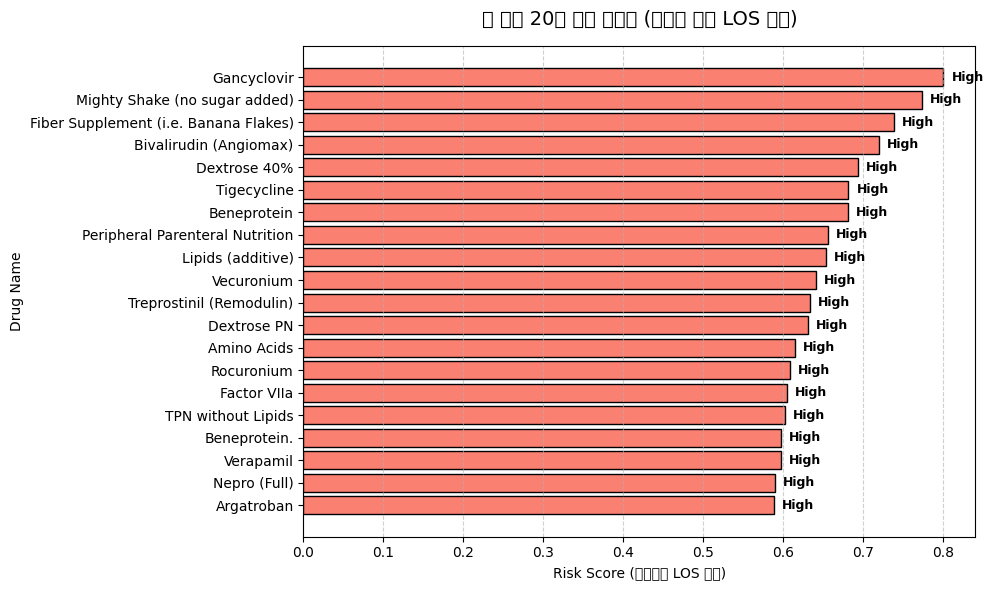

In [ ]:
top20_risky = drug_stats.sort_values('risk_score', ascending=False).head(20)


plt.figure(figsize=(10, 6))
bars = plt.barh(top20_risky.index[::-1], top20_risky['risk_score'][::-1], color='salmon', edgecolor='black')


for i, (score, cat) in enumerate(zip(top20_risky['risk_score'][::-1], top20_risky['risk_category'][::-1])):
    plt.text(score + 0.01, i, cat, va='center', fontsize=9, color='black', fontweight='bold')

plt.title('💊 상위 20개 약물 위험도 (데이터 기반 LOS 기준)', fontsize=14, pad=15)
plt.xlabel('Risk Score (표준화된 LOS 기반)')
plt.ylabel('Drug Name')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
drug_stats['risk_category'].value_counts(dropna=False)


,count
risk_category,
Low,74
Medium,74
High,74
NaN,16


In [ ]:
nan_score_drugs = drug_stats[drug_stats['risk_score'].isna()]
print(f"⚠️ risk_score가 NaN인 약물 수: {len(nan_score_drugs)}개")


nan_drug_names = nan_score_drugs.index.tolist()
print("\n💊 risk_score가 NaN인 약물 목록:")
for i, name in enumerate(nan_drug_names, 1):
    print(f"{i}. {name}")


⚠️ risk_score가 NaN인 약물 수: 16개

💊 risk_score가 NaN인 약물 목록:
1. Optisource
2. Nepro (1/2)
3. Chocolate Scandi Shake (mixed)
4. Bivalirudin (Angiomax) (Impella)
5. Carafate (Sucralfate)
6. Foscarnet
7. Imipenem/Cilastatin
8. Insulin - U500
9. Valgancyclovir
10. Rifampin
11. Impact with Fiber (1/4)
12. Resource Fruit Beverage
13. Moxifloxacin
14. Ertapenem sodium (Invanz)
15. Pamidronate
16. Dextrose 30%


In [ ]:
nan_score_drugs[['mean', 'std', 'count']]


,mean,std,count
drug,,,
Optisource,21.584954,NaN,1
Nepro (1/2),21.079282,NaN,1
Chocolate Scandi Shake (mixed),20.613796,NaN,1
Bivalirudin (Angiomax) (Impella),19.790255,NaN,1
Carafate (Sucralfate),17.270937,NaN,1
Foscarnet,17.034618,NaN,1
Imipenem/Cilastatin,15.019294,NaN,1
Insulin - U500,13.239248,NaN,1
Valgancyclovir,11.177176,NaN,1


In [ ]:
X = drug_stats[['risk_score']].copy()
X_scaled = StandardScaler().fit_transform(X)


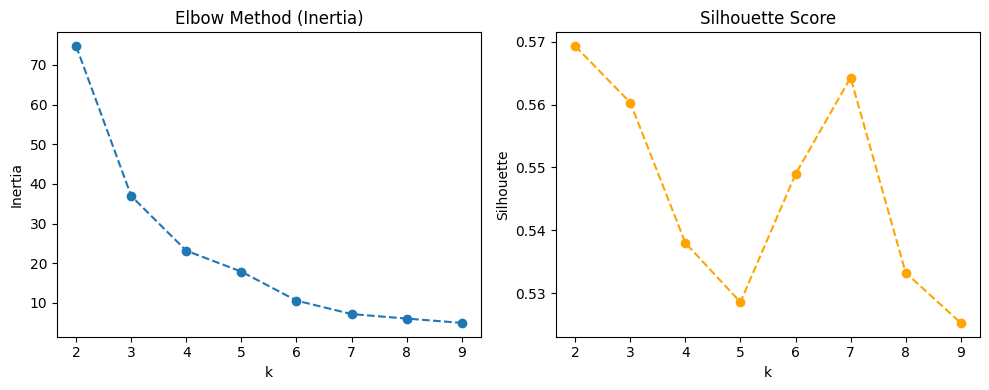

In [ ]:
X = drug_stats[['risk_score']].dropna().copy()



X_scaled = StandardScaler().fit_transform(X)

inertia, silhouette = [], []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'o--')
plt.title('Elbow Method (Inertia)')
plt.xlabel('k'); plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(K_range, silhouette, 'o--', color='orange')
plt.title('Silhouette Score')
plt.xlabel('k'); plt.ylabel('Silhouette')
plt.tight_layout()
plt.show()


In [ ]:
nan_drugs = drug_stats[drug_stats['risk_score'].isna()].copy()
nan_drugs['risk_category'] = 'Sparse'

df_cluster = drug_stats.dropna(subset=['risk_score']).copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[['risk_score']])


kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['risk_cluster'] = kmeans.fit_predict(X_scaled)


cluster_order = (
    df_cluster.groupby('risk_cluster')['risk_score']
    .mean()
    .sort_values()
    .index
)
mapping = {c: i for i, c in enumerate(cluster_order)}
df_cluster['risk_level'] = df_cluster['risk_cluster'].map(mapping)


labels = ['Low', 'Medium', 'High', 'Very High']
df_cluster['risk_category'] = df_cluster['risk_level'].map({i: lbl for i, lbl in enumerate(labels)})

final_risk = pd.concat([df_cluster, nan_drugs], axis=0)

print("✅ 클러스터 기반 4단계 위험도 + Sparse 군 분리 완료")
print(final_risk['risk_category'].value_counts())


✅ 클러스터 기반 4단계 위험도 + Sparse 군 분리 완료
risk_category
Medium    98
High      65
Low       59
Sparse    16
Name: count, dtype: int64


In [ ]:
usage_stats = (
    df_binary.drop(columns=['subject_id'])
    .melt(id_vars='total_LOS', var_name='drug', value_name='used')
    .query('used == 1')
    .groupby('drug')
    .agg(
        usage_count=('used', 'count'),
        mean_LOS=('total_LOS', 'mean')
    )
)

final_risk = final_risk.merge(usage_stats, left_index=True, right_index=True, how='left')


In [ ]:
for cat in ['Low', 'Medium', 'High', 'Sparse']:
    subset = final_risk[final_risk['risk_category'] == cat]
    print(f"\n=== 💊 {cat} 위험도 그룹 (총 {len(subset)}개 약물) 예시 5개 ===")
    display(
        subset[['risk_score', 'usage_count', 'mean_LOS']]
        .sort_values('risk_score', ascending=False)
        .head(10)
    )



=== 💊 Low 위험도 그룹 (총 59개 약물) 예시 5개 ===


,risk_score,usage_count,mean_LOS
drug,,,
OR Colloid Intake,0.320707,317,5.451433
Hydromorphone (Dilaudid),0.319809,1924,5.974407
Doxycycline,0.318115,92,5.771309
Naloxone (Narcan),0.315669,43,4.754738
Epinephrine,0.313891,723,5.400048
Piggyback,0.304679,3535,6.141124
Phenylephrine (50/250),0.303565,1583,5.469171
PACU PO Intake,0.299049,27,4.306247
Protamine sulfate,0.296451,79,4.558237



=== 💊 Medium 위험도 그룹 (총 98개 약물) 예시 5개 ===


,risk_score,usage_count,mean_LOS
drug,,,
Jevity 1.2 (Full),0.484946,308,10.005390
IV Immune Globulin (IVIG),0.482459,63,9.312963
Calcium Chloride,0.479917,107,8.713158
Mannitol,0.476701,94,9.107011
Ceftaroline,0.476199,12,8.061277
Methadone Hydrochloride,0.475685,19,8.218955
Levofloxacin,0.475281,97,9.129839
Lidocaine,0.474043,50,8.639377
Free Water,0.470608,1564,10.208615



=== 💊 High 위험도 그룹 (총 65개 약물) 예시 5개 ===


,risk_score,usage_count,mean_LOS
drug,,,
Gancyclovir,0.800206,8,18.864349
Mighty Shake (no sugar added),0.773073,3,13.934745
Fiber Supplement (i.e. Banana Flakes),0.738818,40,18.329792
Bivalirudin (Angiomax),0.719852,24,15.807255
Dextrose 40%,0.692864,3,11.740475
Tigecycline,0.681494,5,17.298461
Beneprotein,0.680902,19,15.019627
Peripheral Parenteral Nutrition,0.655326,10,12.745396
Lipids (additive),0.653631,35,14.470375



=== 💊 Sparse 위험도 그룹 (총 16개 약물) 예시 5개 ===


,risk_score,usage_count,mean_LOS
drug,,,
Optisource,NaN,1,21.584954
Nepro (1/2),NaN,1,21.079282
Chocolate Scandi Shake (mixed),NaN,1,20.613796
Bivalirudin (Angiomax) (Impella),NaN,1,19.790255
Carafate (Sucralfate),NaN,1,17.270937
Foscarnet,NaN,1,17.034618
Imipenem/Cilastatin,NaN,1,15.019294
Insulin - U500,NaN,1,13.239248
Valgancyclovir,NaN,1,11.177176


# **emar으로 하려다 실패**

In [ ]:
!pip install rapidfuzz

In [ ]:
db_path = '/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db'
conn = sqlite3.connect(db_path)

def clean_text(x):
    """
    약물명 / 제품명 / 성분명 등의 텍스트를 표준화된 형태로 정리
    - 소문자 변환
    - 특수문자 제거
    - 단위명 제거 (mg, ml, tablet 등)
    """
    if pd.isna(x):
        return ''
    x = x.lower()
    x = re.sub(r'[^a-z0-9\s]', ' ', x)
    x = re.sub(r'\b(mg|ml|tab|tablet|inj|infusion|solution|soln|capsule|syringe|unit|units|hr|dose|%|mcg)\b', '', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x

print("✅ 전처리 함수 및 DB 연결 완료")


✅ 전처리 함수 및 DB 연결 완료


In [ ]:

query_emar = """
SELECT subject_id, medication, charttime
FROM emar
WHERE medication IS NOT NULL;
"""
emar = pd.read_sql_query(query_emar, conn)


emar['charttime'] = pd.to_datetime(emar['charttime'], errors='coerce')


emar['med_clean'] = emar['medication'].apply(clean_text)


def is_valid_drug_name(x):
    """
    EMAR의 약물명 중 임상시험 코드명, placebo, 연구약 등 제거
    """
    if pd.isna(x):
        return False
    x = x.lower().strip()


    invalid_patterns = [
        r'\b(study|trial|placebo|investigational|inv|ocr|azd|gs|b\d+|by\d+|ot\d+|h\d+)\b',
        r'^[a-z0-9]{1,3}$',
        r'\b(formulary|interchange|pharmacy)\b',
        r'\b(medication|dose|flush|study drug)\b',
    ]
    for p in invalid_patterns:
        if re.search(p, x):
            return False
    return True


emar = emar[emar['med_clean'].apply(is_valid_drug_name)].copy()


unique_drugs = emar['med_clean'].nunique()
print(f"✅ 필터링 후 EMAR 내 고유 약물 종류 수: {unique_drugs}개")


print("\n📋 필터링 후 상위 20개 약물명:")
print(emar['med_clean'].value_counts().head(20))


💊 EMAR 내 고유 약물 종류 수: 4239개

📋 상위 20개 약물명:
med_clean
sodium chloride 0 9 flush      4573964
insulin                        2596000
heparin                        1904928
acetaminophen                  1744256
hydromorphone dilaudid         1105064
docusate sodium                 980576
oxycodone immediate release     960695
metoprolol tartrate             752497
senna                           693840
gabapentin                      565383
pantoprazole                    469154
lidocaine 5 patch               467691
furosemide                      464672
aspirin                         444204
atorvastatin                    366866
polyethylene glycol             364448
ipratropium albuterol neb       345748
lorazepam                       341606
vancomycin                      324844
omeprazole                      322252
Name: count, dtype: int64


In [ ]:

query_input = """
SELECT DISTINCT itemid, label
FROM d_items
WHERE linksto = 'inputevents';
"""
input_items = pd.read_sql_query(query_input, conn)


input_items['label_clean'] = input_items['label'].apply(clean_text)

print(f"✅ InputEvents 기반 약물 정의 수: {len(input_items)}개")
print("\n📋 상위 10개 항목:")
print(input_items.head(10))


✅ InputEvents 기반 약물 정의 수: 476개

📋 상위 10개 항목:
   itemid                label       label_clean
0  220861  Albumin (Human) 20%  albumin human 20
1  220862          Albumin 25%        albumin 25
2  220863   Albumin (Human) 4%   albumin human 4
3  220864           Albumin 5%         albumin 5
4  220865          Aquadestila       aquadestila
5  220866               Darrow            darrow
6  220949          Dextrose 5%        dextrose 5
7  220950         Dextrose 10%       dextrose 10
8  220951        Dextrose 20.%       dextrose 20
9  220952         Dextrose 50%       dextrose 50


In [ ]:
tqdm.pandas()

def match_to_inputevent(med_name, reference_list):
    """
    EMAR의 약물명(med_name)을 InputEvents 기준의 label_clean과 비교해
    가장 유사한 항목(label_clean)을 반환
    """
    if not isinstance(med_name, str) or med_name.strip() == "":
        return None, 0

    result = process.extractOne(
        med_name,
        reference_list,
        scorer=fuzz.token_sort_ratio
    )
    if result is None:
        return None, 0

    match_label, score, _ = result

    return (match_label if score >= 75 else None), score



reference_list = input_items['label_clean'].dropna().unique().tolist()

emar_unique = emar[['med_clean']].drop_duplicates().reset_index(drop=True)

emar_unique[['matched_label', 'match_score']] = emar_unique['med_clean'].progress_apply(
    lambda x: pd.Series(match_to_inputevent(x, reference_list))
)


emar_matched = emar.merge(emar_unique, on='med_clean', how='left')


total_unique = emar_unique['med_clean'].nunique()
matched_count = emar_unique['matched_label'].notna().sum()
match_rate = 100 * matched_count / total_unique

print(f"✅ 총 {total_unique}개 중 {matched_count}개 매칭 성공 ({match_rate:.2f}%)")


100%|██████████| 4239/4239 [00:01<00:00, 3567.60it/s]


✅ 총 4239개 중 288개 매칭 성공 (6.79%)


In [ ]:

print("✅ [상위 매칭 예시 - 잘 매칭된 약물들]\n")
top_matches = (
    emar_unique[emar_unique['matched_label'].notna()]
    .sort_values('match_score', ascending=False)
    .head(20)
)
print(top_matches[['med_clean', 'matched_label', 'match_score']].to_string(index=False))

print("\n⚠️ [하위 매칭 예시 - 매칭이 어려운 약물들]\n")
low_matches = (
    emar_unique
    .sort_values('match_score', ascending=True)
    .head(20)
)
print(low_matches[['med_clean', 'matched_label', 'match_score']].to_string(index=False))


✅ [상위 매칭 예시 - 잘 매칭된 약물들]

          med_clean       matched_label  match_score
         nesiritide          nesiritide        100.0
     acetylcysteine      acetylcysteine        100.0
          oxacillin           oxacillin        100.0
         folic acid          folic acid        100.0
           atropine            atropine        100.0
            tamiflu             tamiflu        100.0
 potassium chloride  potassium chloride        100.0
   morphine sulfate    morphine sulfate        100.0
          cefazolin           cefazolin        100.0
     norepinephrine      norepinephrine        100.0
potassium phosphate potassium phosphate        100.0
         gentamicin          gentamicin        100.0
           dopamine            dopamine        100.0
           thiamine            thiamine        100.0
         daptomycin          daptomycin        100.0
            esmolol             esmolol        100.0
           propofol            propofol        100.0
          nafcillin 

# **약물 안정화지수 검토해보기**

In [ ]:

filtered_los = patient_drug_los[(patient_drug_los['total_LOS'] >= 1) & (patient_drug_los['total_LOS'] <= 30)].copy()
print(f"✅ LOS 1~30일 사이 환자 수: {len(filtered_los)}명")

n_null = filtered_los['medications_used'].isna().sum()
print(f"⚠️ 투여 약물 기록이 없는 환자 수: {n_null}명 ({100 * n_null / len(filtered_los):.2f}%)")

filtered_los = filtered_los[filtered_los['medications_used'].notna()].reset_index(drop=True)
print(f"✅ 약물 기록이 있는 환자 수 (최종): {len(filtered_los)}명")

✅ LOS 1~30일 사이 환자 수: 13646명
⚠️ 투여 약물 기록이 없는 환자 수: 3704명 (27.14%)
✅ 약물 기록이 있는 환자 수 (최종): 9942명


In [ ]:
def load_vitals_in_batches(conn, icu_df, batch_size=800):
    all_vitals = []
    total = len(icu_df)
    for i in range(0, total, batch_size):
        batch = icu_df.iloc[i:i+batch_size]
        conds = []
        for _, r in batch.iterrows():
            start = r['first_intime']
            end = r['first_intime'] + timedelta(hours=48)
            conds.append(f"(subject_id={r['subject_id']} AND charttime BETWEEN '{start}' AND '{end}')")
        where_clause = " OR ".join(conds)

        query = f"""
        SELECT subject_id, stay_id, charttime, itemid, valuenum
        FROM chartevents
        WHERE itemid IN (220045,220179,220181,220210,220277,223761)
        AND valuenum IS NOT NULL
        AND ({where_clause});
        """
        vitals_part = pd.read_sql_query(query, conn)
        all_vitals.append(vitals_part)
        print(f"✅ Loaded batch {i//batch_size + 1}: {len(vitals_part):,} rows")
    return pd.concat(all_vitals, ignore_index=True)

# 실행
conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')
vitals = load_vitals_in_batches(conn, filtered_los, batch_size=800)
conn.close()

print(f"\n✅ 생체신호 데이터 로드 완료 (총 {len(vitals):,}건)")


✅ Loaded batch 1: 161,816 rows
✅ Loaded batch 2: 163,536 rows
✅ Loaded batch 3: 161,635 rows
✅ Loaded batch 4: 160,726 rows
✅ Loaded batch 5: 166,071 rows
✅ Loaded batch 6: 164,455 rows
✅ Loaded batch 7: 161,233 rows
✅ Loaded batch 8: 164,159 rows
✅ Loaded batch 9: 164,579 rows
✅ Loaded batch 10: 163,879 rows
✅ Loaded batch 11: 165,512 rows
✅ Loaded batch 12: 164,975 rows
✅ Loaded batch 13: 70,159 rows

✅ 생체신호 데이터 로드 완료 (총 2,032,735건)


In [ ]:

import os


save_path = "/content/drive/MyDrive/DataAnalytics/vitals_48h_filtered.csv"


os.makedirs(os.path.dirname(save_path), exist_ok=True)


vitals.to_csv(save_path, index=False)
print(f"💾 파일 저장 완료: {save_path}")

print(f"✅ 저장된 데이터: {len(vitals):,}행 × {len(vitals.columns)}열")
print("컬럼 목록:", list(vitals.columns))
print("\n📊 예시 데이터:")
print(vitals.head())


💾 파일 저장 완료: /content/drive/MyDrive/DataAnalytics/vitals_48h_filtered.csv
✅ 저장된 데이터: 2,032,735행 × 5열
컬럼 목록: ['subject_id', 'stay_id', 'charttime', 'itemid', 'valuenum']

📊 예시 데이터:
   subject_id   stay_id            charttime  itemid  valuenum
0    10002114  34672098  2162-02-19 19:00:00  220277      99.0
1    10002114  34672098  2162-02-19 20:00:00  220045     103.0
2    10002114  34672098  2162-02-19 20:00:00  220210      21.0
3    10002114  34672098  2162-02-19 20:00:00  220277      93.0
4    10002114  34672098  2162-02-19 20:00:00  223761      97.7


In [ ]:

conn = sqlite3.connect("/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db")

query = """
SELECT itemid, label
FROM d_items
WHERE itemid IN (220277, 220045, 220210, 223761);
"""
mapping = pd.read_sql_query(query, conn)
print(mapping)


   itemid                        label
0  220045                   Heart Rate
1  220210             Respiratory Rate
2  220277  O2 saturation pulseoxymetry
3  223761       Temperature Fahrenheit


📊 항목별 결측 비율 (상위 10개):
              label  missing_ratio
0  Temperature (°F)       0.857829
1            220181       0.608330
2            220179       0.606959
3  Respiratory Rate       0.392435
4     O₂ Saturation       0.391736
5        Heart Rate       0.379607


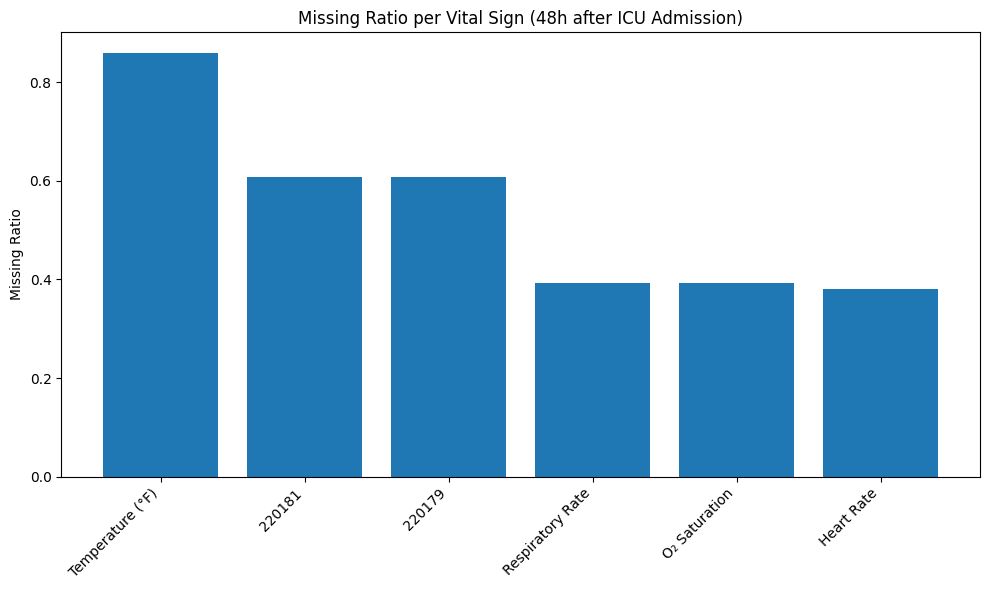

🧩 Overall Missing Ratio: 53.95%


In [ ]:
vitals = pd.read_csv("/content/drive/MyDrive/DataAnalytics/vitals_48h_filtered.csv")

item_map = {
    220045: "Heart Rate",
    220210: "Respiratory Rate",
    220277: "O₂ Saturation",
    223761: "Temperature (°F)"
}


vitals['charttime'] = pd.to_datetime(vitals['charttime'])
vitals = vitals.sort_values(['stay_id', 'charttime'])


pivot_vitals = vitals.pivot_table(
    index=['stay_id', 'charttime'],
    columns='itemid',
    values='valuenum'
)

missing_ratio = pivot_vitals.isna().mean().sort_values(ascending=False)
missing_ratio_df = missing_ratio.reset_index()
missing_ratio_df.columns = ['itemid', 'missing_ratio']


missing_ratio_df['label'] = missing_ratio_df['itemid'].map(item_map)
missing_ratio_df['label'] = missing_ratio_df['label'].fillna(missing_ratio_df['itemid'].astype(str))

print("📊 항목별 결측 비율 (상위 10개):")
print(missing_ratio_df[['label', 'missing_ratio']].head(10))


plt.figure(figsize=(10,6))
plt.bar(missing_ratio_df['label'], missing_ratio_df['missing_ratio'])
plt.title("Missing Ratio per Vital Sign (48h after ICU Admission)")
plt.ylabel("Missing Ratio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ====== 8️⃣ 전체 결측 통계 ======
total_missing = pivot_vitals.isna().sum().sum()
total_values = pivot_vitals.size
print(f"🧩 Overall Missing Ratio: {total_missing / total_values:.2%}")


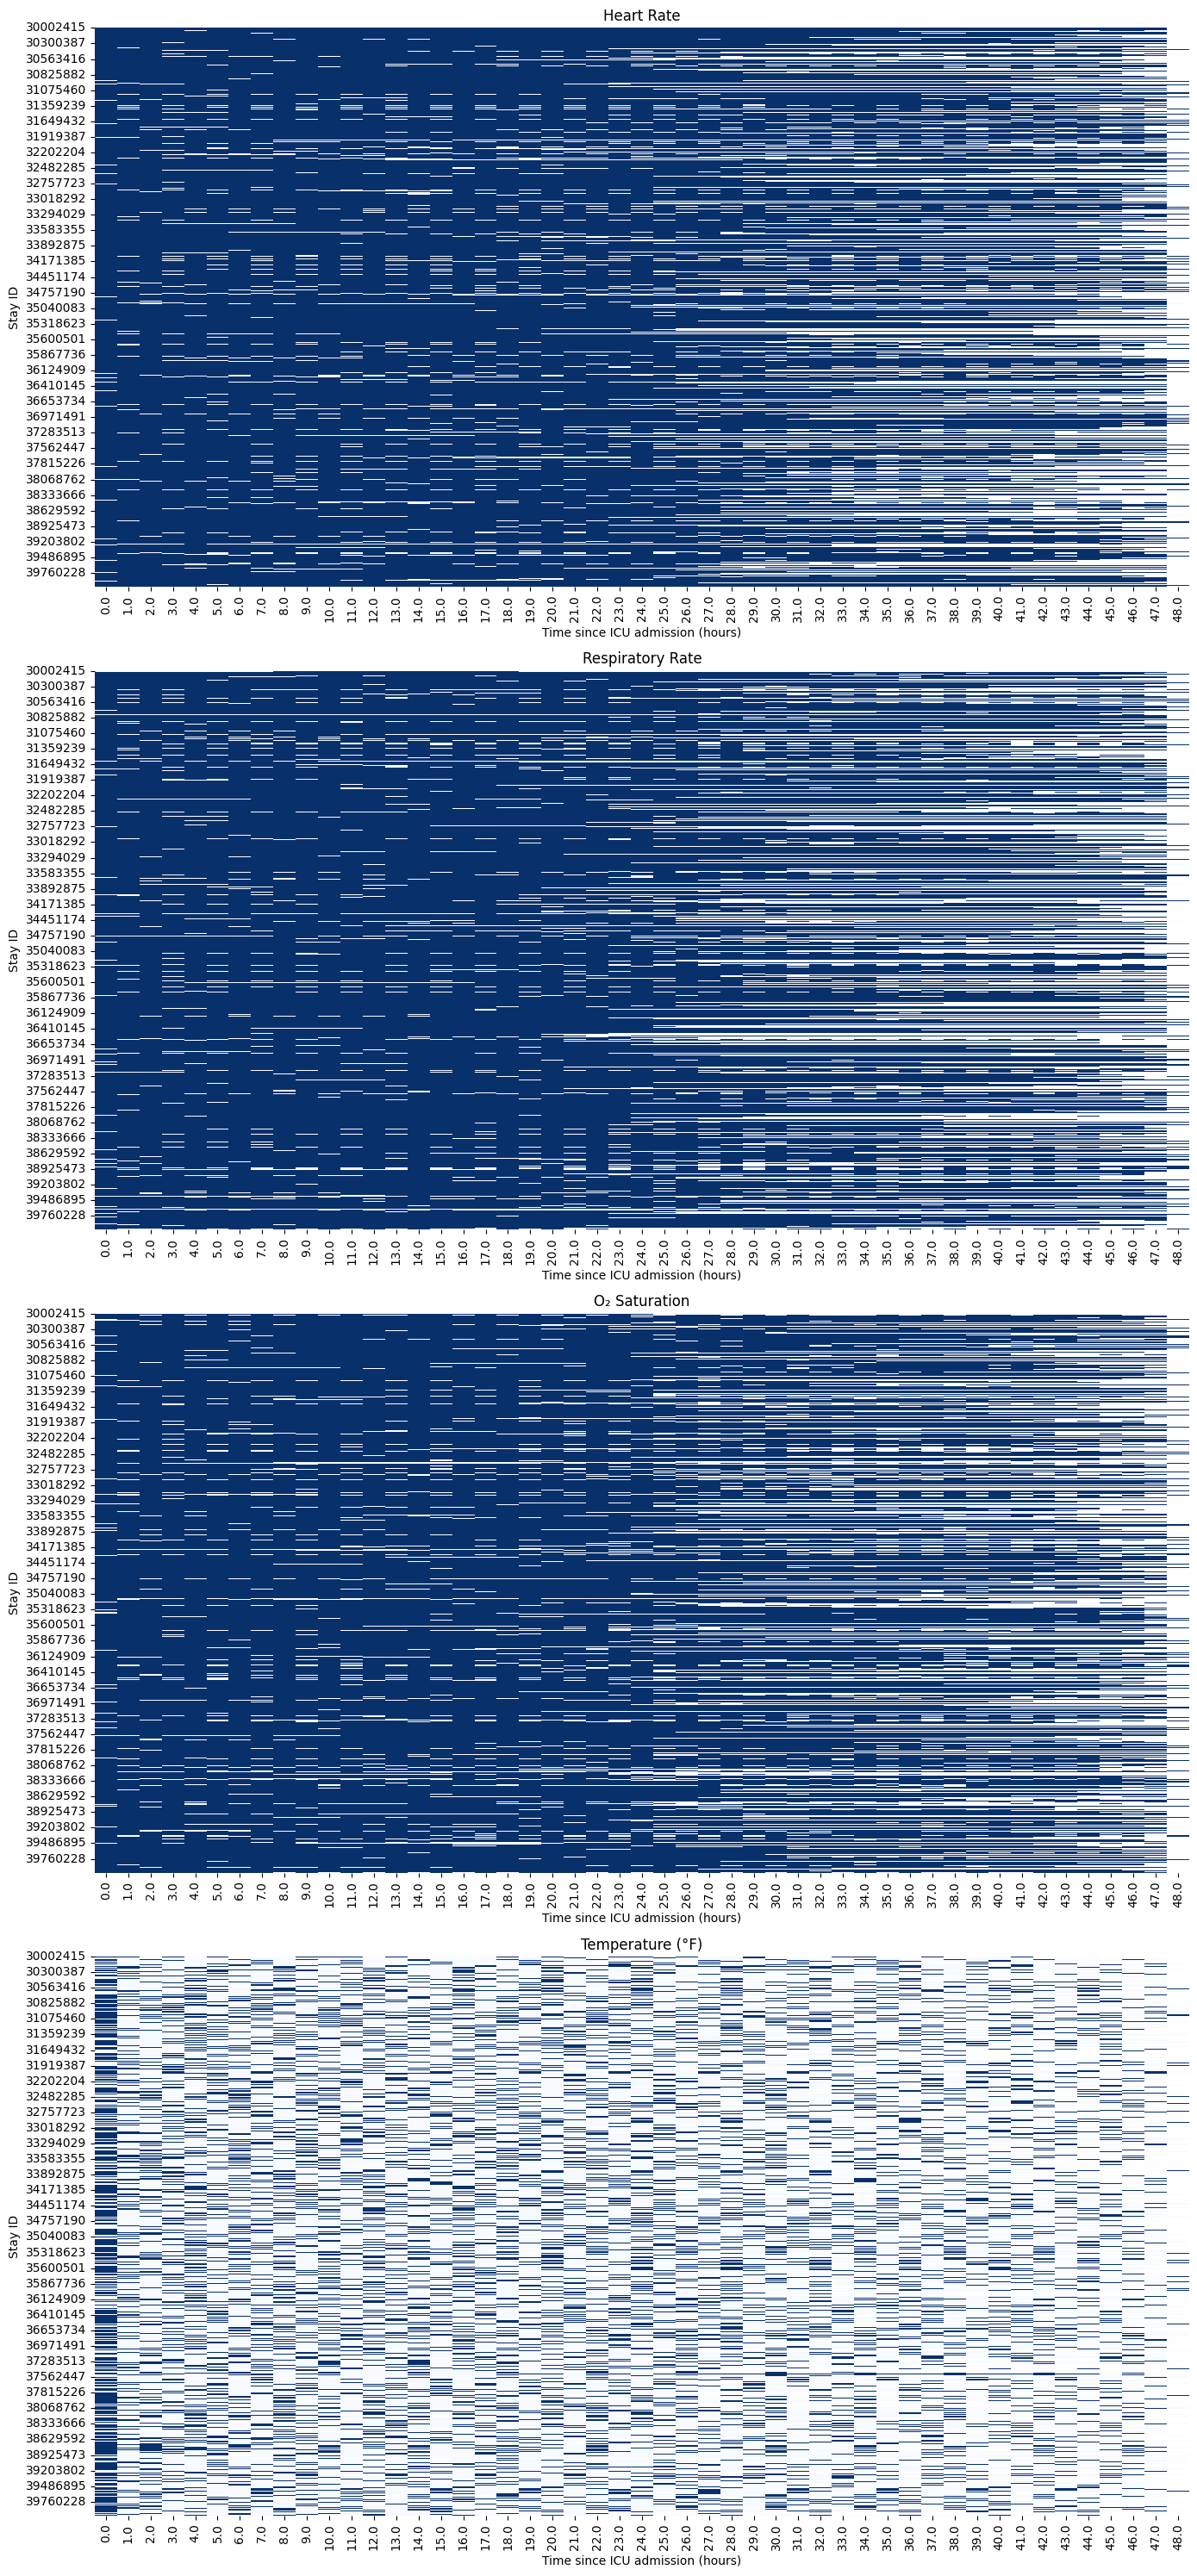

In [ ]:

vitals = pd.read_csv("/content/drive/MyDrive/DataAnalytics/vitals_48h_filtered.csv")
vitals['charttime'] = pd.to_datetime(vitals['charttime'])


item_map = {
    220045: "Heart Rate",
    220210: "Respiratory Rate",
    220277: "O₂ Saturation",
    223761: "Temperature (°F)"
}


vitals['charttime_hour'] = vitals.groupby('stay_id')['charttime'].transform(lambda x: (x - x.min()).dt.total_seconds() / 3600)
vitals['charttime_hour'] = vitals['charttime_hour'].round(0)


heatmap_data = (
    vitals
    .groupby(['stay_id', 'charttime_hour', 'itemid'])
    .size()
    .unstack(fill_value=0)
)


heatmap_data = (heatmap_data > 0).astype(int)


plt.figure(figsize=(14, 30))

for idx, itemid in enumerate(item_map.keys()):
    plt.subplot(len(item_map), 1, idx+1)
    sns.heatmap(
        heatmap_data[itemid].unstack(level=0).T,
        cmap="Blues",
        cbar=False
    )
    plt.title(item_map[itemid])
    plt.xlabel("Time since ICU admission (hours)")
    plt.ylabel("Stay ID")

plt.tight_layout()
plt.show()


In [ ]:

conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')


query_icu = """
SELECT i.subject_id, i.hadm_id, i.stay_id, i.intime, i.outtime
FROM icustays i
JOIN patients p ON i.subject_id = p.subject_id
WHERE p.anchor_year_group IN ('2017 - 2019', '2020 - 2022');
"""
icu = pd.read_sql_query(query_icu, conn)


icu['intime'] = pd.to_datetime(icu['intime'], errors='coerce')
icu['outtime'] = pd.to_datetime(icu['outtime'], errors='coerce')
icu = icu.dropna(subset=['intime', 'outtime'])

icu['LOS_days'] = (icu['outtime'] - icu['intime']).dt.total_seconds() / (60 * 60 * 24)


patient_los = (
    icu.groupby('subject_id', as_index=False)
       .agg(
           n_stays=('stay_id', 'count'),
           total_LOS=('LOS_days', 'sum'),
           first_intime=('intime', 'min'),
           last_outtime=('outtime', 'max')
       )
)


single_stay_patients = patient_los[patient_los['n_stays'] == 1].copy()
print(f"✅ 단일 입원 환자 수: {len(single_stay_patients)}명")


query_input = """
SELECT subject_id, itemid, starttime, endtime, amount, rate, amountuom, rateuom
FROM inputevents
WHERE itemid IS NOT NULL;
"""
inputevents = pd.read_sql_query(query_input, conn)
conn.close()


inputevents['starttime'] = pd.to_datetime(inputevents['starttime'], errors='coerce')
inputevents['endtime'] = pd.to_datetime(inputevents['endtime'], errors='coerce')


merged = inputevents.merge(
    single_stay_patients[['subject_id', 'first_intime', 'last_outtime']],
    on='subject_id', how='inner'
)


filtered = merged[
    ((merged['starttime'] >= merged['first_intime']) & (merged['starttime'] <= merged['last_outtime'])) |
    ((merged['endtime'] >= merged['first_intime']) & (merged['endtime'] <= merged['last_outtime']))
]


filtered_48h = filtered[
    (filtered['starttime'] - filtered['first_intime']).dt.total_seconds() / 3600 <= 48
]


conn = sqlite3.connect('/content/drive/MyDrive/DataAnalytics/MIMIC4-hosp-icu.db')
d_items = pd.read_sql_query("SELECT itemid, label FROM d_items WHERE linksto='inputevents';", conn)
conn.close()

filtered_48h = filtered_48h.merge(d_items, on='itemid', how='left')


drug_48h_df = (
    filtered_48h.groupby('subject_id')
    .apply(lambda x: pd.DataFrame({
        'medications_used': [list(sorted(x['label'].dropna().unique()))],
        'total_amount': [x['amount'].sum(skipna=True)],
        'avg_rate': [x['rate'].mean(skipna=True)]
    }))
    .reset_index(level=1, drop=True)
    .reset_index()
)


drug_48h_df = drug_48h_df[drug_48h_df['medications_used'].str.len() > 0]


drug_48h_df = single_stay_patients.merge(drug_48h_df, on='subject_id', how='inner')


print("✅ 단일 입원 환자별 48시간 내 투여된 약물 및 용량 요약:")
print(drug_48h_df[['subject_id', 'total_LOS', 'medications_used', 'total_amount', 'avg_rate']].head(10))


✅ 단일 입원 환자 수: 16868명
✅ 단일 입원 환자별 48시간 내 투여된 약물 및 용량 요약:
   subject_id  total_LOS                                   medications_used  \
0    10002114   2.907257  [Calcium Gluconate, Dexmedetomidine (Precedex)...   
1    10002348   9.792512                          [Gastric Meds, PO Intake]   
2    10002443   2.750729  [Cefazolin, Dextrose 5%, Furosemide (Lasix), I...   
3    10002667   1.951921  [Acetaminophen-IV, Cefazolin, Dextrose 5%, Fen...   
4    10004606   5.166100  [Calcium Gluconate, Dextrose 5%, Famotidine (P...   
5    10004764   2.489248  [Acetaminophen-IV, Albumin 5%, Cefazolin, Dext...   
6    10005123   1.927708  [Alteplase (TPA), Dextrose 5%, Heparin Sodium,...   
7    10005606   6.595347  [Acetaminophen-IV, Albumin 5%, Calcium Glucona...   
8    10006441   0.776481                  [LR, Morphine Sulfate, PO Intake]   
9    10008077   1.073553  [Dextrose 5%, Heparin Sodium, Morphine Sulfate...   

   total_amount    avg_rate  
0  13316.238303   33.783699  
1   2380.00000

/tmp/ipython-input-2124573447.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


📊 약물 관련 지표와 LOS 간 상관계수:
total_LOS            1.000000
dose_change_count    0.363911
num_drugs            0.240632
avg_rate_per_drug    0.003583
avg_dose_per_drug   -0.041936
Name: total_LOS, dtype: float64


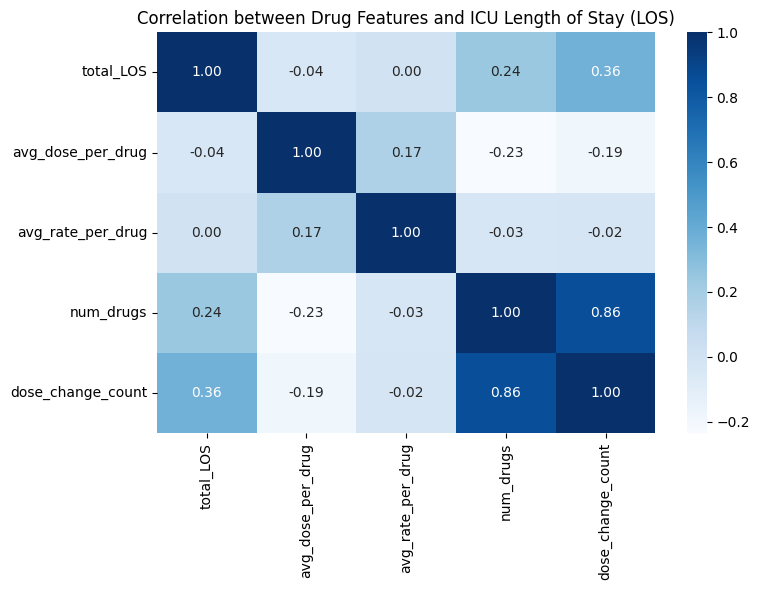

In [ ]:

drug_stats = (
    filtered_48h.groupby(['subject_id', 'label'], as_index=False)
    .agg(
        mean_amount=('amount', 'mean'),
        mean_rate=('rate', 'mean'),
        n_records=('starttime', 'count')
    )
)


drug_features = (
    drug_stats.groupby('subject_id', as_index=False)
    .agg(
        avg_dose_per_drug=('mean_amount', 'mean'),
        avg_rate_per_drug=('mean_rate', 'mean'),
        num_drugs=('label', 'nunique'),
        dose_change_count=('n_records', 'sum')
    )
)


corr_df = single_stay_patients.merge(
    drug_features,
    on='subject_id',
    how='inner'
)[['total_LOS', 'avg_dose_per_drug', 'avg_rate_per_drug', 'num_drugs', 'dose_change_count']]


corr_df = corr_df.dropna()


corr_matrix = corr_df.corr()

print("📊 약물 관련 지표와 LOS 간 상관계수:")
print(corr_matrix['total_LOS'].sort_values(ascending=False))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation between Drug Features and ICU Length of Stay (LOS)")
plt.tight_layout()
plt.show()
